# AMR CUDA Implementation

This notebook compiles and runs the Pure CUDA implementation of the Adaptive Mesh Refinement (AMR) code.

## 1. Check GPU Status

In [49]:
!nvidia-smi

Sun Dec  7 15:37:43 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Write Source Files

In [50]:
%%writefile config.hpp
#pragma once
#include <vector>
#include <cstdint>

struct AMRConfig {
    // Grid Resolution
    int max_level = 21;
    
    // Physics Parameters
    std::vector<double> center = {0.5, 0.5, 0.5};
    double radius = 0.25;
    double bandwidth = 0.05;
    
    // Refinement Limits
    int coarse_level = 4;
    int fine_level = 10;

    uint64_t domain_width() const {
        return 1ULL << max_level;
    }

    // Helper to get integer center based on dimension
    std::vector<uint64_t> get_int_center(int ndim) const {
        uint64_t w = domain_width();
        std::vector<uint64_t> int_c;
        int_c.reserve(ndim);
        for(int i=0; i<ndim; ++i) {
            int_c.push_back(static_cast<uint64_t>(center[i] * w));
        }
        return int_c;
    }

    uint64_t get_int_radius() const {
        return static_cast<uint64_t>(radius * domain_width());
    }

    uint64_t get_int_bandwidth() const {
        return static_cast<uint64_t>(bandwidth * domain_width());
    }
};


Overwriting config.hpp


In [51]:
%%writefile morton.hpp
#pragma once
#include <cstdint>
#include <utility>
#include <tuple>

class Morton2D {
    static const uint64_t MASK_1 = 0x00000000FFFFFFFF;
    static const uint64_t MASK_2 = 0x0000FFFF0000FFFF;
    static const uint64_t MASK_3 = 0x00FF00FF00FF00FF;
    static const uint64_t MASK_4 = 0x0F0F0F0F0F0F0F0F;
    static const uint64_t MASK_5 = 0x3333333333333333;
    static const uint64_t MASK_6 = 0x5555555555555555;

public:
    static uint64_t spread(uint64_t n) {
        n &= MASK_1;
        n = (n | (n << 16)) & MASK_2;
        n = (n | (n << 8))  & MASK_3;
        n = (n | (n << 4))  & MASK_4;
        n = (n | (n << 2))  & MASK_5;
        n = (n | (n << 1))  & MASK_6;
        return n;
    }

    static uint64_t compact(uint64_t n) {
        n &= MASK_6;
        n = (n | (n >> 1)) & MASK_5;
        n = (n | (n >> 2)) & MASK_4;
        n = (n | (n >> 4)) & MASK_3;
        n = (n | (n >> 8)) & MASK_2;
        n = (n | (n >> 16)) & MASK_1;
        return n;
    }

    static uint64_t encode(uint32_t x, uint32_t y) {
        return (spread(y) << 1) | spread(x);
    }

    static std::pair<uint32_t, uint32_t> decode(uint64_t code) {
        return { static_cast<uint32_t>(compact(code)), static_cast<uint32_t>(compact(code >> 1)) };
    }

    // Returns UINT64_MAX if neighbor is invalid
    static uint64_t get_neighbor(uint64_t code, int level, int dx, int dy, int max_level = 21) {
        auto [x, y] = decode(code);
        uint64_t size = 1ULL << (max_level - level);
        
        // Use int64 for arithmetic to handle negative steps, but check bounds carefully
        int64_t nx = static_cast<int64_t>(x) + dx * static_cast<int64_t>(size);
        int64_t ny = static_cast<int64_t>(y) + dy * static_cast<int64_t>(size);
        int64_t limit = 1ULL << max_level;

        if (nx < 0 || nx >= limit || ny < 0 || ny >= limit) return UINT64_MAX;
        
        return encode(static_cast<uint32_t>(nx), static_cast<uint32_t>(ny));
    }
};

class Morton3D {
    static const uint64_t MASK_1 = 0x1FFFFF;
    static const uint64_t MASK_2 = 0x1F00000000FFFF;
    static const uint64_t MASK_3 = 0x1F0000FF0000FF;
    static const uint64_t MASK_4 = 0x100F00F00F00F00F;
    static const uint64_t MASK_5 = 0x10C30C30C30C30C3;
    static const uint64_t MASK_6 = 0x1249249249249249;

public:
    static uint64_t spread(uint64_t n) {
        n &= MASK_1;
        n = (n | (n << 32)) & MASK_2;
        n = (n | (n << 16)) & MASK_3;
        n = (n | (n << 8))  & MASK_4;
        n = (n | (n << 4))  & MASK_5;
        n = (n | (n << 2))  & MASK_6;
        return n;
    }

    static uint64_t compact(uint64_t n) {
        n &= MASK_6;
        n = (n | (n >> 2))  & MASK_5;
        n = (n | (n >> 4))  & MASK_4;
        n = (n | (n >> 8))  & MASK_3;
        n = (n | (n >> 16)) & MASK_2;
        n = (n | (n >> 32)) & MASK_1;
        return n;
    }

    static uint64_t encode(uint32_t x, uint32_t y, uint32_t z) {
        return (spread(z) << 2) | (spread(y) << 1) | spread(x);
    }

    static std::tuple<uint32_t, uint32_t, uint32_t> decode(uint64_t code) {
        return { 
            static_cast<uint32_t>(compact(code)), 
            static_cast<uint32_t>(compact(code >> 1)), 
            static_cast<uint32_t>(compact(code >> 2)) 
        };
    }

    static uint64_t get_neighbor(uint64_t code, int level, int dx, int dy, int dz, int max_level = 21) {
        auto [x, y, z] = decode(code);
        uint64_t size = 1ULL << (max_level - level);
        
        int64_t nx = static_cast<int64_t>(x) + dx * static_cast<int64_t>(size);
        int64_t ny = static_cast<int64_t>(y) + dy * static_cast<int64_t>(size);
        int64_t nz = static_cast<int64_t>(z) + dz * static_cast<int64_t>(size);
        int64_t limit = 1ULL << max_level;

        if (nx < 0 || nx >= limit || ny < 0 || ny >= limit || nz < 0 || nz >= limit) return UINT64_MAX;
        
        return encode(static_cast<uint32_t>(nx), static_cast<uint32_t>(ny), static_cast<uint32_t>(nz));
    }
};


Overwriting morton.hpp


In [52]:
%%writefile tree.hpp
#pragma once
#include <vector>
#include <cstdint>
#include <algorithm>
#include <unordered_map>
#include <unordered_set>
#include <type_traits>
#include "morton.hpp"

class CircleOracle2D;

#ifdef USE_CUDA
// Forward declarations for CUDA
#include <cuda_runtime.h>
void refineCUDA_pure(uint64_t** d_codes_ptr, int** d_levels_ptr, int* n_nodes,
                     const void* oracle_data, int max_level);
void balanceCUDA_pure(uint64_t** d_codes_ptr, int** d_levels_ptr, int* n_nodes,
                      int max_level, int max_iter);
#endif

struct Node {
    uint64_t code;
    int level;

    bool operator<(const Node& other) const {
        return code < other.code;
    }
    bool operator==(const Node& other) const {
        return code == other.code && level == other.level;
    }
};

// Abstract Linear Tree logic implemented via Templates
template <int DIM>
class LinearTree {
public:
    int max_level;
    std::vector<Node> leaves;
    bool use_gpu;

#ifdef USE_CUDA
    uint64_t* d_codes = nullptr;
    int* d_levels = nullptr;
    int d_size = 0;
    bool gpu_dirty = false;
#endif

    LinearTree(int max_lvl = 21, bool use_gpu_flag = false) 
        : max_level(max_lvl), use_gpu(use_gpu_flag) {
        leaves.push_back({0, 0});
#ifdef USE_CUDA
        if (use_gpu) {
            syncToGPU();
        }
#endif
    }

    ~LinearTree() {
#ifdef USE_CUDA
        if (d_codes) cudaFree(d_codes);
        if (d_levels) cudaFree(d_levels);
#endif
    }

    uint64_t domain_width() const { return 1ULL << max_level; }

    // Helpers to bridge Morton2D/3D differences
    std::vector<uint64_t> decode_coords(uint64_t code) const;
    uint64_t encode_coords(const std::vector<uint64_t>& coords) const;
    uint64_t get_neighbor_code(uint64_t code, int level, const std::vector<int>& offset) const;

    // Returns (coords, size)
    std::pair<std::vector<uint64_t>, uint64_t> get_geometry(const Node& node) const {
        auto coords = decode_coords(node.code);
        uint64_t size = 1ULL << (max_level - node.level);
        return {coords, size};
    }

#ifdef USE_CUDA
    void syncToGPU() {
        if (d_codes) cudaFree(d_codes);
        if (d_levels) cudaFree(d_levels);
        
        d_size = leaves.size();
        cudaMalloc(&d_codes, d_size * sizeof(uint64_t));
        cudaMalloc(&d_levels, d_size * sizeof(int));
        
        std::vector<uint64_t> codes(d_size);
        std::vector<int> levels(d_size);
        for(int i=0; i<d_size; ++i) {
            codes[i] = leaves[i].code;
            levels[i] = leaves[i].level;
        }
        
        cudaMemcpy(d_codes, codes.data(), d_size * sizeof(uint64_t), cudaMemcpyHostToDevice);
        cudaMemcpy(d_levels, levels.data(), d_size * sizeof(int), cudaMemcpyHostToDevice);
        gpu_dirty = false;
    }

    void syncFromGPU() {
        leaves.resize(d_size);
        std::vector<uint64_t> codes(d_size);
        std::vector<int> levels(d_size);
        
        cudaMemcpy(codes.data(), d_codes, d_size * sizeof(uint64_t), cudaMemcpyDeviceToHost);
        cudaMemcpy(levels.data(), d_levels, d_size * sizeof(int), cudaMemcpyDeviceToHost);
        
        for(int i=0; i<d_size; ++i) {
            leaves[i] = {codes[i], levels[i]};
        }
        gpu_dirty = false;
    }
#endif

    // Refine
    template <typename Oracle>
    bool refine(Oracle& oracle) {
#ifdef USE_CUDA
        // Only attempt GPU refine if the Oracle is of a supported type
        // We use a simple name check or trait here. For now, let's assume CircleOracle2D.
        // In a real system we'd use a trait like is_gpu_compatible<Oracle>::value
        if (use_gpu) {
            if constexpr (std::is_same_v<Oracle, CircleOracle2D>) {
                if (gpu_dirty) syncToGPU();
                
                auto oracle_data = oracle.get_gpu_data(max_level);
                int before = d_size;
                refineCUDA_pure(&d_codes, &d_levels, &d_size, &oracle_data, max_level);
                
                syncFromGPU();
                return d_size != before;
            }
        }
#endif

        std::vector<Node> new_leaves;
        // Optimization: Reserve memory
        new_leaves.reserve(leaves.size()); 
        
        bool has_changed = false;

        // Base offsets for children
        std::vector<std::vector<int>> offsets;
        if constexpr (DIM == 2) {
            offsets = {{0,0}, {1,0}, {0,1}, {1,1}};
        } else {
            offsets = {{0,0,0}, {1,0,0}, {0,1,0}, {1,1,0},
                       {0,0,1}, {1,0,1}, {0,1,1}, {1,1,1}};
        }

        for (const auto& node : leaves) {
            if (oracle(node, max_level)) {
                has_changed = true;
                auto current_coords = decode_coords(node.code);
                int new_lvl = node.level + 1;
                uint64_t step = 1ULL << (max_level - new_lvl);

                for (const auto& offset : offsets) {
                    std::vector<uint64_t> child_coords = current_coords;
                    for(size_t i=0; i<DIM; ++i) child_coords[i] += offset[i] * step;
                    
                    new_leaves.push_back({encode_coords(child_coords), new_lvl});
                }
            } else {
                new_leaves.push_back(node);
            }
        }

        if (has_changed) {
            std::sort(new_leaves.begin(), new_leaves.end());
            leaves = std::move(new_leaves);
        }
        return has_changed;
    }

    // Balance (2:1 Constraint)
    void balance() {
#ifdef USE_CUDA
        if (use_gpu) {
            if (gpu_dirty) syncToGPU();
            balanceCUDA_pure(&d_codes, &d_levels, &d_size, max_level, 20);
            syncFromGPU();
            return;
        }
#endif

        int max_iter = 20;

        // Generate direction vectors (excluding 0,0...)
        std::vector<std::vector<int>> directions;
        if constexpr (DIM == 2) {
            for(int x=-1; x<=1; ++x) for(int y=-1; y<=1; ++y)
                if(x!=0 || y!=0) directions.push_back({x, y});
        } else {
            for(int x=-1; x<=1; ++x) for(int y=-1; y<=1; ++y) for(int z=-1; z<=1; ++z)
                if(x!=0 || y!=0 || z!=0) directions.push_back({x, y, z});
        }

        for (int iter = 0; iter < max_iter; ++iter) {
            // 1. Build map for O(1) lookups
            // Note: In extremely high performance C++, we might use binary_search on 'leaves' directly
            // instead of building a map, but a map is safer for translation logic.
            std::unordered_map<uint64_t, Node> node_map;
            node_map.reserve(leaves.size());
            for(const auto& n : leaves) node_map[n.code] = n;

            std::unordered_set<uint64_t> to_refine_codes;

            // 2. Scan
            for (const auto& node : leaves) {
                int min_valid_level = node.level - 1;
                if (min_valid_level < 1) continue;

                for (const auto& dir : directions) {
                    uint64_t base_n_code = get_neighbor_code(node.code, node.level, dir);
                    if (base_n_code == UINT64_MAX) continue;

                    // Search coarser levels
                    int curr_search_level = node.level - 2;
                    while (curr_search_level >= 0) {
                        int shift_bits = (max_level - curr_search_level) * DIM;
                        uint64_t mask = ~((1ULL << shift_bits) - 1ULL);

                        uint64_t coarse_n_code = base_n_code & mask;

                        if (to_refine_codes.count(coarse_n_code)) break;

                        auto it = node_map.find(coarse_n_code);
                        if (it != node_map.end()) {
                            if (it->second.level == curr_search_level) {
                                to_refine_codes.insert(it->second.code);
                                break;
                            }
                        }
                        curr_search_level--;
                    }
                }
            }

            // 3. Batch Refine
            if (to_refine_codes.empty()) break;

            // Lambda for refinement
            auto refine_predicate = [&](const Node& n, int) {
                return to_refine_codes.count(n.code) > 0;
            };
            refine(refine_predicate);
        }
    }
};

// Template specializations for 2D/3D specifics
template<> inline std::vector<uint64_t> LinearTree<2>::decode_coords(uint64_t code) const {
    auto [x, y] = Morton2D::decode(code);
    return {x, y};
}
template<> inline uint64_t LinearTree<2>::encode_coords(const std::vector<uint64_t>& c) const {
    return Morton2D::encode((uint32_t)c[0], (uint32_t)c[1]);
}
template<> inline uint64_t LinearTree<2>::get_neighbor_code(uint64_t code, int level, const std::vector<int>& off) const {
    return Morton2D::get_neighbor(code, level, off[0], off[1], max_level);
}

template<> inline std::vector<uint64_t> LinearTree<3>::decode_coords(uint64_t code) const {
    auto [x, y, z] = Morton3D::decode(code);
    return {x, y, z};
}
template<> inline uint64_t LinearTree<3>::encode_coords(const std::vector<uint64_t>& c) const {
    return Morton3D::encode((uint32_t)c[0], (uint32_t)c[1], (uint32_t)c[2]);
}
template<> inline uint64_t LinearTree<3>::get_neighbor_code(uint64_t code, int level, const std::vector<int>& off) const {
    return Morton3D::get_neighbor(code, level, off[0], off[1], off[2], max_level);
}

// Aliases
using Quadtree = LinearTree<2>;
using Octree   = LinearTree<3>;


Overwriting tree.hpp


In [53]:
%%writefile physics.hpp
#pragma once
#include "config.hpp"
#include "morton.hpp"
#include "tree.hpp"

// GPU Data structure
struct CircleOracleData {
    uint64_t cx, cy;
    uint64_t radius_sq;
    uint64_t bandwidth;
    uint64_t radius;
    int coarse_level;
    int fine_level;
};

class CircleOracle2D {
    AMRConfig config;
    uint64_t cx, cy;
    uint64_t radius_sq;
    uint64_t bandwidth;
    
public:
    CircleOracle2D(const AMRConfig& cfg) : config(cfg) {
        auto centers = cfg.get_int_center(2);
        cx = centers[0]; cy = centers[1];
        bandwidth = cfg.get_int_bandwidth();
    }

    // Helper to get GPU data
    CircleOracleData get_gpu_data(int max_level) const {
        CircleOracleData data;
        data.cx = cx;
        data.cy = cy;
        data.bandwidth = bandwidth;
        data.radius = config.get_int_radius();
        data.coarse_level = config.coarse_level;
        data.fine_level = config.fine_level;
        return data;
    }

    bool operator()(const Node& node, int max_level_grid) {
        // 1. Decode
        auto [x, y] = Morton2D::decode(node.code);
        uint64_t size = 1ULL << (max_level_grid - node.level);

        // 2. Node Center (using double for distance calc to be safe with large squares)
        double node_cx = x + size * 0.5;
        double node_cy = y + size * 0.5;

        // 3. Sq Distance
        double dx = node_cx - cx;
        double dy = node_cy - cy;
        double dist_sq = dx*dx + dy*dy;

        // 4. Bounds
        double extent = size * 0.70710678; // size * sqrt(2)/2
        double threshold = bandwidth + extent;

        double r = static_cast<double>(config.get_int_radius());
        double upper = r + threshold;
        double lower = r - threshold;
        
        double upper_sq = upper * upper;
        double lower_sq = (lower < 0) ? 0.0 : lower * lower;

        // 5. Check
        bool is_refining = (dist_sq < upper_sq) && (dist_sq > lower_sq);

        return (node.level < config.coarse_level) || 
               (is_refining && node.level < config.fine_level);
    }
};

class SphereOracle3D {
    AMRConfig config;
    uint64_t cx, cy, cz;
    uint64_t bandwidth;

public:
    SphereOracle3D(const AMRConfig& cfg) : config(cfg) {
        auto centers = cfg.get_int_center(3);
        cx = centers[0]; cy = centers[1]; cz = centers[2];
        bandwidth = cfg.get_int_bandwidth();
    }

    bool operator()(const Node& node, int max_level_grid) {
        auto [x, y, z] = Morton3D::decode(node.code);
        uint64_t size = 1ULL << (max_level_grid - node.level);

        double node_cx = x + size * 0.5;
        double node_cy = y + size * 0.5;
        double node_cz = z + size * 0.5;

        double dx = node_cx - cx;
        double dy = node_cy - cy;
        double dz = node_cz - cz;
        double dist_sq = dx*dx + dy*dy + dz*dz;

        // Extent = size * sqrt(3) / 2
        double extent = size * 0.8660254;
        double threshold = bandwidth + extent;

        double r = static_cast<double>(config.get_int_radius());
        double upper = r + threshold;
        double lower = r - threshold;

        double upper_sq = upper * upper;
        double lower_sq = (lower < 0) ? 0.0 : lower * lower;

        bool is_refining = (dist_sq < upper_sq) && (dist_sq > lower_sq);

        return (node.level < config.coarse_level) || 
               (is_refining && node.level < config.fine_level);
    }
};


Overwriting physics.hpp


In [54]:
%%writefile main.cpp
#include <iostream>
#include <iomanip>
#include <chrono>
#include <cstring>
#include <fstream>
#include "config.hpp"
#include "tree.hpp"
#include "physics.hpp"

#ifdef USE_CUDA
#include "cuda_utils.cuh"
#endif

class MeshVisualizer {
public:
    // Exports the Quadtree to an SVG file viewable in any browser
    static void save_svg(const Quadtree& tree, const std::string& filename) {
        std::ofstream file(filename);
        if (!file.is_open()) {
            std::cerr << "Error: Could not open file " << filename << std::endl;
            return;
        }

        uint64_t limit = tree.domain_width();
        double scale_factor = 1000.0 / limit; // Map domain to 1000x1000 pixels

        // SVG Header
        file << "<svg xmlns=\"http://www.w3.org/2000/svg\" version=\"1.1\" "
             << "width=\"1000\" height=\"1000\" viewBox=\"0 0 1000 1000\">\n";
        
        // Background
        file << "<rect width=\"1000\" height=\"1000\" fill=\"white\"/>\n";

        // Draw Leaves
        for (const auto& node : tree.leaves) {
            auto [coords, size] = tree.get_geometry(node);
            
            // SVG coordinate system has (0,0) at top-left. 
            // We need to flip Y to match standard cartesian (bottom-left).
            double x = coords[0] * scale_factor;
            double raw_y = coords[1] * scale_factor;
            double h = size * scale_factor;
            double y = 1000.0 - raw_y - h; // Flip Y

            file << "<rect x=\"" << x << "\" y=\"" << y 
                 << "\" width=\"" << h << "\" height=\"" << h 
                 << "\" style=\"fill:none;stroke:red;stroke-width:0.5\" />\n";
        }

        // Add Title/Info text
        file << "<text x=\"10\" y=\"25\" font-family=\"Arial\" font-size=\"20\" fill=\"black\">"
             << "Elements: " << tree.leaves.size() << "</text>\n";

        file << "</svg>";
        file.close();
        std::cout << "[Viz] Saved 2D mesh to " << filename << std::endl;
    }
};

int main(int argc, char** argv) {
    bool use_cuda = false;
    
    // Parse command-line arguments
    for (int i = 1; i < argc; i++) {
        if (strcmp(argv[i], "--cuda") == 0 || strcmp(argv[i], "--gpu") == 0) {
            use_cuda = true;
        } else if (strcmp(argv[i], "--help") == 0 || strcmp(argv[i], "-h") == 0) {
            std::cout << "Usage: " << argv[0] << " [options]" << std::endl;
            std::cout << "Options:" << std::endl;
            std::cout << "  --cuda, --gpu    Use CUDA GPU acceleration" << std::endl;
            std::cout << "  --help, -h       Show this help message" << std::endl;
            return 0;
        }
    }
    
#ifdef USE_CUDA
    if (use_cuda) {
        std::cout << "--- C++ AMR with CUDA Acceleration ---" << std::endl;
        cuda_utils::printGPUInfo();
        std::cout << std::endl;
    } else {
        std::cout << "--- C++ AMR (CPU Mode) ---" << std::endl;
    }
#else
    if (use_cuda) {
        std::cout << "WARNING: CUDA requested but not compiled. Running in CPU mode." << std::endl;
    }
    use_cuda = false;
    std::cout << "--- C++ AMR (CPU Only) ---" << std::endl;
#endif
    
    AMRConfig cfg;
    cfg.max_level = 20; 
    cfg.fine_level = 12;
    cfg.coarse_level = 3;
    cfg.center = {0.5, 0.5};
    cfg.radius = 0.25;

    // Parse configuration arguments
    for (int i = 1; i < argc; i++) {
        if (strcmp(argv[i], "--max_level") == 0 && i + 1 < argc) {
            cfg.max_level = std::atoi(argv[++i]);
        } else if (strcmp(argv[i], "--fine_level") == 0 && i + 1 < argc) {
            cfg.fine_level = std::atoi(argv[++i]);
        }
    }

    std::cout << "Config: 2D Quadtree, MaxLvl=" << cfg.max_level << std::endl;
    std::cout << "Mode: " << (use_cuda ? "GPU" : "CPU") << std::endl;

    Quadtree tree(cfg.max_level, use_cuda);
    CircleOracle2D oracle(cfg);

    int max_steps = 16;
    
    std::cout << std::left << std::setw(10) << "Step" 
              << "| " << std::setw(15) << "Elements" 
              << "| " << std::setw(12) << "Time (ms)" << std::endl;
    std::cout << std::string(45, '-') << std::endl;

    auto total_start = std::chrono::high_resolution_clock::now();
    
    for(int step = 0; step < max_steps; ++step) {
        auto step_start = std::chrono::high_resolution_clock::now();
        
        bool changed = tree.refine(oracle);
        
        auto step_end = std::chrono::high_resolution_clock::now();
        auto duration = std::chrono::duration_cast<std::chrono::milliseconds>(step_end - step_start);
        
        std::cout << std::left << std::setw(10) << step 
                  << "| " << std::setw(15) << tree.leaves.size() 
                  << "| " << std::setw(12) << duration.count() << std::endl;

        if (!changed) {
            std::cout << "Converged early." << std::endl;
            break;
        }
    }

    std::cout << "\nRunning Balance Constraint..." << std::endl;
    size_t before = tree.leaves.size();
    
    auto balance_start = std::chrono::high_resolution_clock::now();
    tree.balance();
    auto balance_end = std::chrono::high_resolution_clock::now();
    
    auto balance_duration = std::chrono::duration_cast<std::chrono::milliseconds>(balance_end - balance_start);
    size_t after = tree.leaves.size();
    
    std::cout << "Balance complete. Elements: " << before << " -> " << after << std::endl;
    std::cout << "Balance time: " << balance_duration.count() << " ms" << std::endl;
    
    auto total_end = std::chrono::high_resolution_clock::now();
    auto total_duration = std::chrono::duration_cast<std::chrono::milliseconds>(total_end - total_start);
    
    std::cout << "\nTotal execution time: " << total_duration.count() << " ms" << std::endl;
    
    // Save SVG
    MeshVisualizer::save_svg(tree, "mesh_2d.svg");

    return 0;
}


Overwriting main.cpp


In [55]:
%%writefile cuda_utils.cuh
#pragma once

#ifdef USE_CUDA

#include <cuda_runtime.h>
#include <cstdio>
#include <cstdlib>
#include <stdexcept>
#include <string>

// CUDA error checking macro
#define CUDA_CHECK(call) \
    do { \
        cudaError_t error = call; \
        if (error != cudaSuccess) { \
            fprintf(stderr, "CUDA error at %s:%d: %s\n", \
                    __FILE__, __LINE__, cudaGetErrorString(error)); \
            throw std::runtime_error(std::string("CUDA error: ") + cudaGetErrorString(error)); \
        } \
    } while(0)

// Kernel launch error checking
#define CUDA_CHECK_LAST() CUDA_CHECK(cudaGetLastError())

// Device synchronization with error checking
#define CUDA_SYNC() CUDA_CHECK(cudaDeviceSynchronize())

namespace cuda_utils {

// Get optimal block size for a kernel
inline int getOptimalBlockSize() {
    return 256; // Good default for most modern GPUs
}

// Calculate grid size given total threads and block size
inline int getGridSize(int n, int blockSize) {
    return (n + blockSize - 1) / blockSize;
}

// Query GPU properties
inline void printGPUInfo() {
    int deviceCount;
    CUDA_CHECK(cudaGetDeviceCount(&deviceCount));
    
    for (int i = 0; i < deviceCount; i++) {
        cudaDeviceProp prop;
        CUDA_CHECK(cudaGetDeviceProperties(&prop, i));
        
        printf("GPU %d: %s\n", i, prop.name);
        printf("  Compute Capability: %d.%d\n", prop.major, prop.minor);
        printf("  Total Global Memory: %.2f GB\n", 
               prop.totalGlobalMem / (1024.0 * 1024.0 * 1024.0));
        printf("  Multiprocessors: %d\n", prop.multiProcessorCount);
        printf("  Max Threads per Block: %d\n", prop.maxThreadsPerBlock);
    }
}

} // namespace cuda_utils

#endif // USE_CUDA


Overwriting cuda_utils.cuh


In [56]:
%%writefile tree_kernels.cuh
#pragma once

#ifdef USE_CUDA

#include <cstdint>

// Forward declarations
void refineCUDA_pure(uint64_t** d_codes_ptr, int** d_levels_ptr, int* n_nodes,
                     const void* oracle_data, int max_level);

void balanceCUDA_pure(uint64_t** d_codes_ptr, int** d_levels_ptr, int* n_nodes,
                      int max_level, int max_iter);

#endif // USE_CUDA


Overwriting tree_kernels.cuh


In [57]:
%%writefile tree_kernels.cu
#ifdef USE_CUDA

#include "tree_kernels.cuh"
#include "cuda_utils.cuh"
#include "physics.hpp" // For CircleOracleData
#include <climits>

// ============================================================================
// MORTON GPU IMPLEMENTATION
// ============================================================================

namespace Morton2D_GPU {
    __device__ __forceinline__ uint64_t spread(uint64_t n) {
        const uint64_t MASK_1 = 0x00000000FFFFFFFF;
        const uint64_t MASK_2 = 0x0000FFFF0000FFFF;
        const uint64_t MASK_3 = 0x00FF00FF00FF00FF;
        const uint64_t MASK_4 = 0x0F0F0F0F0F0F0F0F;
        const uint64_t MASK_5 = 0x3333333333333333;
        const uint64_t MASK_6 = 0x5555555555555555;
        
        n &= MASK_1;
        n = (n | (n << 16)) & MASK_2;
        n = (n | (n << 8))  & MASK_3;
        n = (n | (n << 4))  & MASK_4;
        n = (n | (n << 2))  & MASK_5;
        n = (n | (n << 1))  & MASK_6;
        return n;
    }

    __device__ __forceinline__ uint64_t compact(uint64_t n) {
        const uint64_t MASK_1 = 0x00000000FFFFFFFF;
        const uint64_t MASK_2 = 0x0000FFFF0000FFFF;
        const uint64_t MASK_3 = 0x00FF00FF00FF00FF;
        const uint64_t MASK_4 = 0x0F0F0F0F0F0F0F0F;
        const uint64_t MASK_5 = 0x3333333333333333;
        const uint64_t MASK_6 = 0x5555555555555555;
        
        n &= MASK_6;
        n = (n | (n >> 1)) & MASK_5;
        n = (n | (n >> 2)) & MASK_4;
        n = (n | (n >> 4)) & MASK_3;
        n = (n | (n >> 8)) & MASK_2;
        n = (n | (n >> 16)) & MASK_1;
        return n;
    }

    __device__ __forceinline__ uint64_t encode(uint64_t x, uint64_t y) {
        return (spread(y) << 1) | spread(x);
    }

    __device__ __forceinline__ void decode(uint64_t code, uint64_t& x, uint64_t& y) {
        x = compact(code);
        y = compact(code >> 1);
    }

    __device__ __forceinline__ uint64_t get_neighbor(uint64_t code, int level, int dx, int dy, int max_level) {
        uint64_t x, y;
        decode(code, x, y);
        
        // Size of the cell at this level
        uint64_t size = 1ULL << (max_level - level);
        
        // Center of the cell (or top-left)
        // Code corresponds to top-left.
        // We want the neighbor of the cell.
        // If dx=1, we want the cell to the right.
        // Its coordinate is x + size.
        // But we need to be careful about overflow/underflow.
        
        long long nx = (long long)x + (long long)dx * size;
        long long ny = (long long)y + (long long)dy * size;
        
        long long limit = 1ULL << max_level;
        
        if (nx < 0 || nx >= limit || ny < 0 || ny >= limit) {
            return UINT64_MAX;
        }
        
        return encode((uint64_t)nx, (uint64_t)ny);
    }
}

// Binary Search to find the node that contains the given code
// Returns index of the node, or -1 if not found
__device__ int findNodeIndex(const uint64_t* codes, const int* levels, int n, uint64_t target_code, int max_level) {
    int left = 0;
    int right = n - 1;
    int ans = -1;
    
    // Find the last node with code <= target_code (upper_bound - 1)
    while (left <= right) {
        int mid = left + (right - left) / 2;
        if (codes[mid] <= target_code) {
            ans = mid;
            left = mid + 1;
        } else {
            right = mid - 1;
        }
    }
    
    if (ans != -1) {
        // Check if this node actually contains the target_code
        // A node covers [code, code + size^2) in Morton space?
        // No, range is [code, code + 4^(max-level))
        // 4^k = 1 << (2*k)
        int level = levels[ans];
        int shift = 2 * (max_level - level);
        // Be careful with 64-bit shift
        uint64_t range = (shift >= 64) ? UINT64_MAX : (1ULL << shift);
        
        if (target_code < codes[ans] + range) {
            return ans;
        }
    }
    
    return -1;
}

// ============================================================================
// PARALLEL PRIMITIVES (PURE CUDA)
// ============================================================================

// Parallel Bitonic Sort Step
__global__ void bitonicSortStep(uint64_t* codes, int* levels, int n, int j, int k) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    int ixj = idx ^ j;
    
    if (ixj > idx && idx < n && ixj < n) {
        if ((idx & k) == 0) {
            // Ascending
            if (codes[idx] > codes[ixj]) {
                // Swap
                uint64_t tc = codes[idx]; codes[idx] = codes[ixj]; codes[ixj] = tc;
                int tl = levels[idx]; levels[idx] = levels[ixj]; levels[ixj] = tl;
            }
        } else {
            // Descending
            if (codes[idx] < codes[ixj]) {
                // Swap
                uint64_t tc = codes[idx]; codes[idx] = codes[ixj]; codes[ixj] = tc;
                int tl = levels[idx]; levels[idx] = levels[ixj]; levels[ixj] = tl;
            }
        }
    }
}

void bitonicSortGPU(uint64_t* d_codes, int* d_levels, int n) {
    // Round up to power of 2
    int n_padded = 1;
    while (n_padded < n) n_padded *= 2;
    
    // Pad if needed
    if (n_padded > n) {
        uint64_t* h_max_codes = new uint64_t[n_padded - n];
        int* h_max_levels = new int[n_padded - n];
        for (int i = 0; i < n_padded - n; i++) {
            h_max_codes[i] = UINT64_MAX;
            h_max_levels[i] = INT_MAX;
        }
        CUDA_CHECK(cudaMemcpy(d_codes + n, h_max_codes, (n_padded - n) * sizeof(uint64_t), cudaMemcpyHostToDevice));
        CUDA_CHECK(cudaMemcpy(d_levels + n, h_max_levels, (n_padded - n) * sizeof(int), cudaMemcpyHostToDevice));
        delete[] h_max_codes;
        delete[] h_max_levels;
    }
    
    int blockSize = 256;
    int gridSize = (n_padded + blockSize - 1) / blockSize;
    
    for (int k = 2; k <= n_padded; k *= 2) {
        for (int j = k / 2; j > 0; j /= 2) {
            bitonicSortStep<<<gridSize, blockSize>>>(d_codes, d_levels, n_padded, j, k);
            CUDA_CHECK_LAST();
        }
    }
}

// Parallel Exclusive Scan (Blelloch)
__global__ void scanUpSweep(int* data, int n, int stride) {
    int idx = (blockIdx.x * blockDim.x + threadIdx.x) * stride * 2;
    if (idx + stride < n) {
        data[idx + stride * 2 - 1] += data[idx + stride - 1];
    }
}

__global__ void scanDownSweep(int* data, int n, int stride) {
    int idx = (blockIdx.x * blockDim.x + threadIdx.x) * stride * 2;
    if (idx + stride < n) {
        int temp = data[idx + stride - 1];
        data[idx + stride - 1] = data[idx + stride * 2 - 1];
        data[idx + stride * 2 - 1] += temp;
    }
}

void exclusiveScanGPU(int* d_data, int n) {
    int n_padded = 1;
    while (n_padded < n) n_padded *= 2;
    
    if (n_padded > n) {
        CUDA_CHECK(cudaMemset(d_data + n, 0, (n_padded - n) * sizeof(int)));
    }
    
    int blockSize = 256;
    
    // Up-sweep
    for (int stride = 1; stride < n_padded; stride *= 2) {
        int gridSize = (n_padded / (stride * 2) + blockSize - 1) / blockSize;
        if (gridSize > 0) {
            scanUpSweep<<<gridSize, blockSize>>>(d_data, n_padded, stride);
            CUDA_CHECK_LAST();
        }
    }
    
    // Set last to 0
    int zero = 0;
    CUDA_CHECK(cudaMemcpy(d_data + n_padded - 1, &zero, sizeof(int), cudaMemcpyHostToDevice));
    
    // Down-sweep
    for (int stride = n_padded / 2; stride >= 1; stride /= 2) {
        int gridSize = (n_padded / (stride * 2) + blockSize - 1) / blockSize;
        if (gridSize > 0) {
            scanDownSweep<<<gridSize, blockSize>>>(d_data, n_padded, stride);
            CUDA_CHECK_LAST();
        }
    }
}

// ============================================================================
// ORACLE & REFINE KERNELS
// ============================================================================

__global__ void evaluateOracleKernel(
    CircleOracleData oracle,
    const uint64_t* codes,
    const int* levels,
    bool* results,
    int n,
    int max_level
) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        uint64_t code = codes[idx];
        int level = levels[idx];
        
        uint64_t x, y;
        Morton2D_GPU::decode(code, x, y);
        
        uint64_t size = 1ULL << (max_level - level);
        
        double node_cx = x + size * 0.5;
        double node_cy = y + size * 0.5;
        
        double dx = node_cx - oracle.cx;
        double dy = node_cy - oracle.cy;
        double dist_sq = dx*dx + dy*dy;
        
        double extent = size * 0.70710678;
        double threshold = oracle.bandwidth + extent;
        
        double r = (double)oracle.radius;
        double upper = r + threshold;
        double lower = r - threshold;
        
        double upper_sq = upper * upper;
        double lower_sq = (lower < 0) ? 0.0 : lower * lower;
        
        bool is_refining = (dist_sq < upper_sq) && (dist_sq > lower_sq);
        
        results[idx] = (level < oracle.coarse_level) || 
                       (is_refining && level < oracle.fine_level);
    }
}

__global__ void markRefinementKernel(
    const bool* oracle_results,
    int* refine_flags,
    int n
) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        refine_flags[idx] = oracle_results[idx] ? 1 : 0;
    }
}

__global__ void countOutputsKernel(
    const int* refine_flags,
    int* output_counts,
    int n
) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        output_counts[idx] = refine_flags[idx] ? 4 : 1;
    }
}

__global__ void expandNodesKernel(
    const uint64_t* parent_codes,
    const int* parent_levels,
    const int* refine_flags,
    const int* scan_results,
    uint64_t* child_codes,
    int* child_levels,
    int n,
    int max_level
) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        if (refine_flags[idx]) {
            uint64_t x, y;
            Morton2D_GPU::decode(parent_codes[idx], x, y);
            
            int new_level = parent_levels[idx] + 1;
            uint64_t step = 1ULL << (max_level - new_level);
            
            int out_base = scan_results[idx]; // Scan gives exclusive sum, so this is start index
            // But wait, scan is on output_counts (4 or 1).
            // If we are thread i, scan[i] is the start index for our children.
            
            // Child 0
            child_codes[out_base + 0] = Morton2D_GPU::encode(x, y);
            child_levels[out_base + 0] = new_level;
            
            // Child 1
            child_codes[out_base + 1] = Morton2D_GPU::encode(x + step, y);
            child_levels[out_base + 1] = new_level;
            
            // Child 2
            child_codes[out_base + 2] = Morton2D_GPU::encode(x, y + step);
            child_levels[out_base + 2] = new_level;
            
            // Child 3
            child_codes[out_base + 3] = Morton2D_GPU::encode(x + step, y + step);
            child_levels[out_base + 3] = new_level;
        } else {
            int out_idx = scan_results[idx];
            child_codes[out_idx] = parent_codes[idx];
            child_levels[out_idx] = parent_levels[idx];
        }
    }
}

void refineCUDA_pure(
    uint64_t** d_codes_ptr,
    int** d_levels_ptr,
    int* n_nodes,
    const void* oracle_data_ptr,
    int max_level
) {
    int n = *n_nodes;
    if (n == 0) return;
    
    const CircleOracleData* oracle = (const CircleOracleData*)oracle_data_ptr;
    
    uint64_t* d_codes = *d_codes_ptr;
    int* d_levels = *d_levels_ptr;
    
    // Allocate temps
    bool* d_oracle_results;
    int* d_refine_flags;
    int* d_output_counts;
    int* d_scan;
    
    CUDA_CHECK(cudaMalloc(&d_oracle_results, n * sizeof(bool)));
    CUDA_CHECK(cudaMalloc(&d_refine_flags, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_output_counts, n * sizeof(int)));
    // Allocate scan array with padding for power of 2
    int n_padded = 1;
    while (n_padded < n) n_padded *= 2;
    CUDA_CHECK(cudaMalloc(&d_scan, n_padded * sizeof(int)));
    
    int blockSize = 256;
    int gridSize = (n + blockSize - 1) / blockSize;
    
    // 1. Evaluate Oracle
    evaluateOracleKernel<<<gridSize, blockSize>>>(
        *oracle, d_codes, d_levels, d_oracle_results, n, max_level
    );
    CUDA_CHECK_LAST();
    
    // 2. Mark Refinement
    markRefinementKernel<<<gridSize, blockSize>>>(
        d_oracle_results, d_refine_flags, n
    );
    CUDA_CHECK_LAST();
    
    // 3. Count Outputs
    countOutputsKernel<<<gridSize, blockSize>>>(
        d_refine_flags, d_output_counts, n
    );
    CUDA_CHECK_LAST();
    
    // 4. Scan
    // Copy counts to scan array
    CUDA_CHECK(cudaMemcpy(d_scan, d_output_counts, n * sizeof(int), cudaMemcpyDeviceToDevice));
    exclusiveScanGPU(d_scan, n);
    
    // 5. Calculate Total Size
    int last_scan, last_count;
    CUDA_CHECK(cudaMemcpy(&last_scan, d_scan + n - 1, sizeof(int), cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(&last_count, d_output_counts + n - 1, sizeof(int), cudaMemcpyDeviceToHost));
    int total_outputs = last_scan + last_count;
    
    if (total_outputs == n) {
        // No changes
        cudaFree(d_oracle_results);
        cudaFree(d_refine_flags);
        cudaFree(d_output_counts);
        cudaFree(d_scan);
        return;
    }
    
    // 6. Allocate New Arrays
    int total_outputs_padded = 1;
    while (total_outputs_padded < total_outputs) total_outputs_padded *= 2;

    uint64_t* d_new_codes;
    int* d_new_levels;
    CUDA_CHECK(cudaMalloc(&d_new_codes, total_outputs_padded * sizeof(uint64_t)));
    CUDA_CHECK(cudaMalloc(&d_new_levels, total_outputs_padded * sizeof(int)));
    
    // 7. Expand
    expandNodesKernel<<<gridSize, blockSize>>>(
        d_codes, d_levels, d_refine_flags, d_scan,
        d_new_codes, d_new_levels, n, max_level
    );
    CUDA_CHECK_LAST();
    
    // 8. Sort
    bitonicSortGPU(d_new_codes, d_new_levels, total_outputs);
    
    // Swap pointers
    cudaFree(d_codes);
    cudaFree(d_levels);
    *d_codes_ptr = d_new_codes;
    *d_levels_ptr = d_new_levels;
    *n_nodes = total_outputs;
    
    // Cleanup
    cudaFree(d_oracle_results);
    cudaFree(d_refine_flags);
    cudaFree(d_output_counts);
    cudaFree(d_scan);
}

__global__ void checkBalanceKernel(
    const uint64_t* codes,
    const int* levels,
    int* refine_flags,
    int n,
    int max_level
) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        int level = levels[idx];
        // If level is too small, we can't have a neighbor at level-2
        if (level < 2) return;
        
        uint64_t code = codes[idx];
        
        // Check 8 neighbors
        for (int dx = -1; dx <= 1; ++dx) {
            for (int dy = -1; dy <= 1; ++dy) {
                if (dx == 0 && dy == 0) continue;
                
                uint64_t n_code = Morton2D_GPU::get_neighbor(code, level, dx, dy, max_level);
                
                if (n_code != UINT64_MAX) {
                    // Find who covers this neighbor code
                    int n_idx = findNodeIndex(codes, levels, n, n_code, max_level);
                    
                    if (n_idx != -1) {
                        int n_level = levels[n_idx];
                        // Constraint: Neighbor cannot be more than 1 level coarser
                        // If n_level <= level - 2, then neighbor is too coarse.
                        // Neighbor must refine.
                        if (n_level <= level - 2) {
                            // Mark neighbor for refinement
                            // Use atomic to be safe, though simple write might work
                            atomicExch(&refine_flags[n_idx], 1);
                        }
                    }
                }
            }
        }
    }
}

void balanceCUDA_pure(
    uint64_t** d_codes_ptr,
    int** d_levels_ptr,
    int* n_nodes,
    int max_level,
    int max_iter
) {
    for (int iter = 0; iter < max_iter; ++iter) {
        int n = *n_nodes;
        if (n == 0) break;
        
        uint64_t* d_codes = *d_codes_ptr;
        int* d_levels = *d_levels_ptr;
        
        // Allocate temps
        int* d_refine_flags;
        int* d_output_counts;
        int* d_scan;
        
        CUDA_CHECK(cudaMalloc(&d_refine_flags, n * sizeof(int)));
        CUDA_CHECK(cudaMemset(d_refine_flags, 0, n * sizeof(int))); // Init to 0
        CUDA_CHECK(cudaMalloc(&d_output_counts, n * sizeof(int)));
        
        int n_padded = 1;
        while (n_padded < n) n_padded *= 2;
        CUDA_CHECK(cudaMalloc(&d_scan, n_padded * sizeof(int)));
        
        int blockSize = 256;
        int gridSize = (n + blockSize - 1) / blockSize;
        
        // 1. Check Balance
        checkBalanceKernel<<<gridSize, blockSize>>>(
            d_codes, d_levels, d_refine_flags, n, max_level
        );
        CUDA_CHECK_LAST();
        
        // 2. Count Outputs
        countOutputsKernel<<<gridSize, blockSize>>>(
            d_refine_flags, d_output_counts, n
        );
        CUDA_CHECK_LAST();
        
        // 3. Scan
        CUDA_CHECK(cudaMemcpy(d_scan, d_output_counts, n * sizeof(int), cudaMemcpyDeviceToDevice));
        exclusiveScanGPU(d_scan, n);
        
        // 4. Calculate Total Size
        int last_scan, last_count;
        CUDA_CHECK(cudaMemcpy(&last_scan, d_scan + n - 1, sizeof(int), cudaMemcpyDeviceToHost));
        CUDA_CHECK(cudaMemcpy(&last_count, d_output_counts + n - 1, sizeof(int), cudaMemcpyDeviceToHost));
        int total_outputs = last_scan + last_count;
        
        if (total_outputs == n) {
            // No changes
            cudaFree(d_refine_flags);
            cudaFree(d_output_counts);
            cudaFree(d_scan);
            break;
        }
        
        // 5. Allocate New Arrays
        int total_outputs_padded = 1;
        while (total_outputs_padded < total_outputs) total_outputs_padded *= 2;

        uint64_t* d_new_codes;
        int* d_new_levels;
        CUDA_CHECK(cudaMalloc(&d_new_codes, total_outputs_padded * sizeof(uint64_t)));
        CUDA_CHECK(cudaMalloc(&d_new_levels, total_outputs_padded * sizeof(int)));
        
        // 6. Expand
        expandNodesKernel<<<gridSize, blockSize>>>(
            d_codes, d_levels, d_refine_flags, d_scan,
            d_new_codes, d_new_levels, n, max_level
        );
        CUDA_CHECK_LAST();
        
        // 7. Sort
        bitonicSortGPU(d_new_codes, d_new_levels, total_outputs);
        
        // Swap pointers
        cudaFree(d_codes);
        cudaFree(d_levels);
        *d_codes_ptr = d_new_codes;
        *d_levels_ptr = d_new_levels;
        *n_nodes = total_outputs;
        
        // Cleanup
        cudaFree(d_refine_flags);
        cudaFree(d_output_counts);
        cudaFree(d_scan);
    }
}

#endif // USE_CUDA


Overwriting tree_kernels.cu


In [58]:
%%writefile CMakeLists.txt
cmake_minimum_required(VERSION 3.18)
project(AMR_CUDA LANGUAGES CXX)

set(CMAKE_CXX_STANDARD 17)
set(CMAKE_CXX_STANDARD_REQUIRED ON)

option(USE_CUDA "Enable CUDA acceleration" OFF)

# Source files
set(SOURCES
    main.cpp
)

if(USE_CUDA)
    enable_language(CUDA)
    find_package(CUDAToolkit REQUIRED)
    
    set(CMAKE_CUDA_STANDARD 17)
    set(CMAKE_CUDA_ARCHITECTURES 75 80 86) # Adjust based on target GPU
    
    add_definitions(-DUSE_CUDA)
    
    list(APPEND SOURCES
        tree_kernels.cu
    )
endif()

add_executable(amr ${SOURCES})

if(USE_CUDA)
    set_target_properties(amr PROPERTIES CUDA_SEPARABLE_COMPILATION OFF)
    # Linking cudart adds the include directories for cuda_runtime.h to main.cpp
    target_link_libraries(amr PRIVATE CUDA::cudart)
endif()


Overwriting CMakeLists.txt


## 3. Build
We use CMake to configure the build with CUDA support.

In [59]:
!mkdir -p build
%cd build
!cmake .. -DUSE_CUDA=ON
!make
%cd ..

/content/build
-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /content/build
[ 33%] Building CXX object CMakeFiles/amr.dir/main.cpp.o
[ 66%] Building CUDA object CMakeFiles/amr.dir/tree_kernels.cu.o
[100%] Linking CXX executable amr
[100%] Built target amr
/content


## 4. Run Single Test
Run the AMR application with CUDA enabled (Max Level 15).

In [63]:
!./build/amr --cuda --max_level 20 --fine_level 12

--- C++ AMR with CUDA Acceleration ---
GPU 0: Tesla T4
  Compute Capability: 7.5
  Total Global Memory: 14.74 GB
  Multiprocessors: 40
  Max Threads per Block: 1024

Config: 2D Quadtree, MaxLvl=20
Mode: GPU
Step      | Elements       | Time (ms)   
---------------------------------------------
0         | 4              | 0           
1         | 16             | 0           
2         | 64             | 0           
3         | 148            | 0           
4         | 364            | 0           
5         | 1072           | 0           
6         | 3412           | 0           
7         | 11956          | 0           
8         | 44488          | 1           
9         | 171436         | 5           
10        | 672388         | 26          
11        | 2662372        | 115         
12        | 2662372        | 29          
Converged early.

Running Balance Constraint...
Balance complete. Elements: 2662372 -> 2677900
Balance time: 392 ms

Total execution time: 574 ms
[Viz] Saved 2

## 6. Benchmark & Speedup Plot
Run a benchmark comparing CPU vs GPU for different max levels.

Running Benchmark...
Testing Max Level 10...
  CPU: 508 ms
  GPU: 498 ms
Testing Max Level 12...
  CPU: 38263 ms
  GPU: 617 ms
Testing Max Level 14...
  CPU: 38528 ms
  GPU: 581 ms
Testing Max Level 16...
  CPU: 39788 ms
  GPU: 571 ms
Testing Max Level 18...
  CPU: 40061 ms
  GPU: 568 ms
Testing Max Level 20...
  CPU: 39400 ms
  GPU: 574 ms


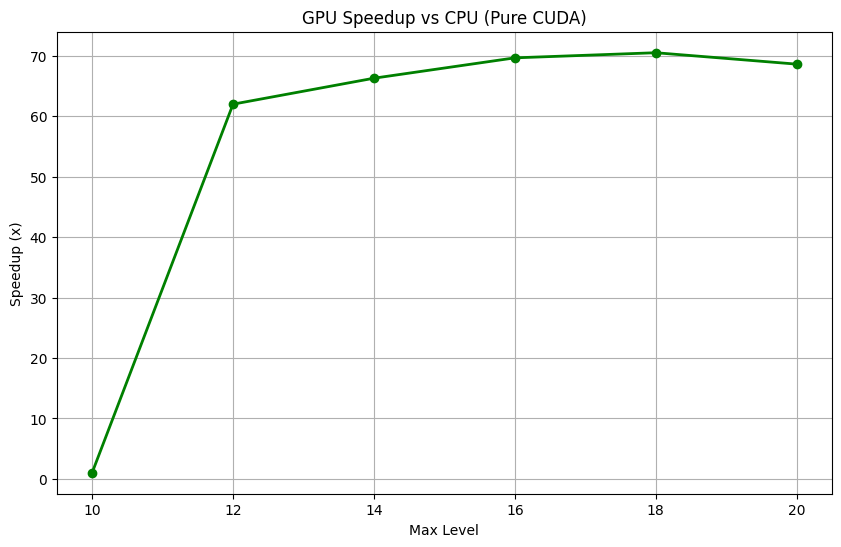

In [61]:
import subprocess
import re
import matplotlib.pyplot as plt

def get_time(cmd):
    try:
        result = subprocess.run(cmd, shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
        output = result.stdout
        match = re.search(r"Total execution time: (\d+) ms", output)
        if match:
            return int(match.group(1))
    except Exception as e:
        print(f"Error running {cmd}: {e}")
    return None

levels = [10, 12, 14, 16, 18, 20]
cpu_times = []
gpu_times = []

print("Running Benchmark...")
for lvl in levels:
    print(f"Testing Max Level {lvl}...")
    
    # CPU
    t_cpu = get_time(f"./build/amr --max_level {lvl}")
    if t_cpu is None: t_cpu = 0
    cpu_times.append(t_cpu)
    print(f"  CPU: {t_cpu} ms")
    
    # GPU
    t_gpu = get_time(f"./build/amr --cuda --max_level {lvl}")
    if t_gpu is None: t_gpu = 0
    gpu_times.append(t_gpu)
    print(f"  GPU: {t_gpu} ms")

speedups = [c/g if g > 0 else 0 for c, g in zip(cpu_times, gpu_times)]

plt.figure(figsize=(10, 6))
plt.plot(levels, speedups, marker='o', linewidth=2, color='green')
plt.title('GPU Speedup vs CPU (Pure CUDA)')
plt.xlabel('Max Level')
plt.ylabel('Speedup (x)')
plt.grid(True)
plt.show()

In [ ]:

# ------------------------------------------------------------
# 2️⃣  Run the benchmark and capture output
# ------------------------------------------------------------
import subprocess, shlex, os, sys, textwrap

# Adjust these arguments as needed for your test
max_level   = 20   # same as you used for the OpenMP run
fine_level  = 12   # same as you used for the OpenMP run
cuda_args   = f"--max_level {max_level} --fine_level {fine_level} --cuda"

# Run the binary and capture stdout+stderr
cmd = f"./build/amr {cuda_args}"
print(f"Running: {cmd}")
result = subprocess.run(shlex.split(cmd), capture_output=True, text=True)

# Write the raw output to a file
out_path = "cuda_benchmark.txt"
with open(out_path, "w") as f:
    f.write(result.stdout)
    f.write("\n--- STDERR ---\n")
    f.write(result.stderr)

print(f"\n✅ Benchmark finished – output saved to `{out_path}`")
print("\n".join(result.stdout.splitlines()[:20]))

# ------------------------------------------------------------
# 3️⃣  Offer the file for download to your local machine
# ------------------------------------------------------------
from google.colab import files
files.download(out_path)

Running: ./build/amr --max_level 20 --fine_level 12 --cuda

✅ Benchmark finished – output saved to `cuda_benchmark.txt`
First 20 lines of the output (for a quick sanity check):
--- C++ AMR with CUDA Acceleration ---
GPU 0: Tesla T4
  Compute Capability: 7.5
  Total Global Memory: 14.74 GB
  Multiprocessors: 40
  Max Threads per Block: 1024

Config: 2D Quadtree, MaxLvl=20
Mode: GPU
Step      | Elements       | Time (ms)   
---------------------------------------------
0         | 4              | 0           
1         | 16             | 0           
2         | 64             | 0           
3         | 148            | 0           
4         | 364            | 0           
5         | 1072           | 0           
6         | 3412           | 0           
7         | 11956          | 0           
8         | 44488          | 1           


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>